In [18]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"] = 100
sns.set_theme(style="whitegrid", palette="muted")

RAW_PATH = Path("../data/raw/ml-100k")
print("Libraries loaded!")

Libraries loaded!


In [19]:
# Ratings — arquivo principal
ratings = pd.read_csv(
    RAW_PATH / "u.data",
    sep="\t",
    names=["user_id", "item_id", "rating", "timestamp"],
)

# Filmes
movies = pd.read_csv(
    RAW_PATH / "u.item",
    sep="|",
    encoding="latin-1",
    names=[
        "item_id",
        "title",
        "release_date",
        "video_release",
        "imdb_url",
        "unknown",
        "Action",
        "Adventure",
        "Animation",
        "Children",
        "Comedy",
        "Crime",
        "Documentary",
        "Drama",
        "Fantasy",
        "Film-Noir",
        "Horror",
        "Musical",
        "Mystery",
        "Romance",
        "Sci-Fi",
        "Thriller",
        "War",
        "Western",
    ],
    usecols=range(24),
)

# Usuários
users = pd.read_csv(
    RAW_PATH / "u.user",
    sep="|",
    names=["user_id", "age", "gender", "occupation", "zip_code"],
)

# Converte timestamp
ratings["datetime"] = pd.to_datetime(ratings["timestamp"], unit="s")

print(f"ratings : {len(ratings):,} linhas")
print(f"movies  : {len(movies):,} filmes")
print(f"users   : {len(users):,} usuários")
print("Head ratings:")
ratings.head()

ratings : 100,000 linhas
movies  : 1,682 filmes
users   : 943 usuários
Head ratings:


,user_id,item_id,rating,timestamp,datetime
0,196,242,3,881250949,1997-12-04 15:55:49
1,186,302,3,891717742,1998-04-04 19:22:22
2,22,377,1,878887116,1997-11-07 07:18:36
3,244,51,2,880606923,1997-11-27 05:02:03
4,166,346,1,886397596,1998-02-02 05:33:16


In [20]:
print("=== OVERVIEW ===\n")
print(
    f"Period: {ratings['datetime'].min().date()} to {ratings['datetime'].max().date()}"
)
print(f"Duration: {(ratings['datetime'].max() - ratings['datetime'].min()).days} days")
print("\nRatings:")
print(f"  Total        : {len(ratings):,}")
print(f"  Users        : {ratings['user_id'].nunique()}")
print(f"  Movies       : {ratings['item_id'].nunique()}")
print(f"  Average rating: {ratings['rating'].mean():.2f}")
print(f"  Min rating   : {ratings['rating'].min()}")
print(f"  Max rating   : {ratings['rating'].max()}")
print("\nMissing values:")
print(ratings.isnull().sum())

=== OVERVIEW ===

Period: 1997-09-20 to 1998-04-22
Duration: 214 days

Ratings:
  Total        : 100,000
  Users        : 943
  Movies       : 1682
  Average rating: 3.53
  Min rating   : 1
  Max rating   : 5

Missing values:
user_id      0
item_id      0
rating       0
timestamp    0
datetime     0
dtype: int64


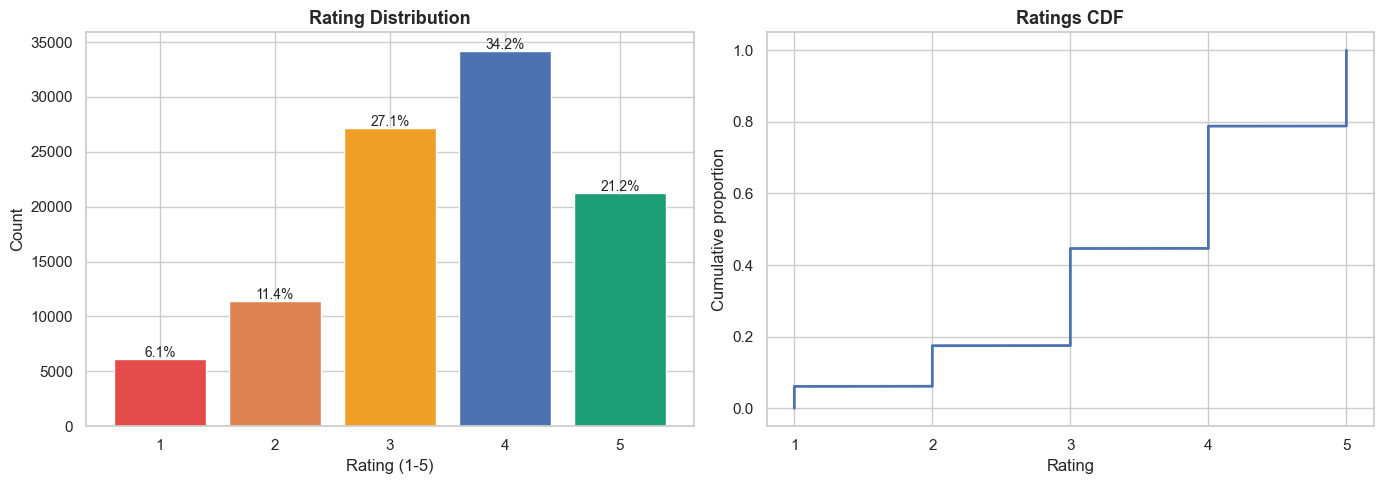

Average rating : 3.53
Median rating  : 4
% ratings >= 4 : 55.4%


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Rating counts
rating_counts = ratings["rating"].value_counts().sort_index()
axes[0].bar(
    rating_counts.index,
    rating_counts.values,
    color=["#E24B4A", "#DD8452", "#EF9F27", "#4C72B0", "#1D9E75"],
    edgecolor="white",
)
axes[0].set_title("Rating Distribution", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Rating (1-5)")
axes[0].set_ylabel("Count")
axes[0].set_xticks([1, 2, 3, 4, 5])
for rating, count in rating_counts.items():
    pct = count / len(ratings) * 100
    axes[0].text(rating, count + 200, f"{pct:.1f}%", ha="center", fontsize=10)

# Cumulative CDF
sorted_ratings = np.sort(ratings["rating"].values)
cdf = np.arange(1, len(sorted_ratings) + 1) / len(sorted_ratings)
axes[1].plot(sorted_ratings, cdf, color="#4C72B0", linewidth=2)
axes[1].set_title("Ratings CDF", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Rating")
axes[1].set_ylabel("Cumulative proportion")
axes[1].set_xticks([1, 2, 3, 4, 5])

plt.tight_layout()
plt.savefig(
    "../notebooks/fig_ml_01_rating_distribution.png", dpi=150, bbox_inches="tight"
)
plt.show()

print(f"Average rating : {ratings['rating'].mean():.2f}")
print(f"Median rating  : {ratings['rating'].median():.0f}")
print(f"% ratings >= 4 : {(ratings['rating'] >= 4).mean():.1%}")

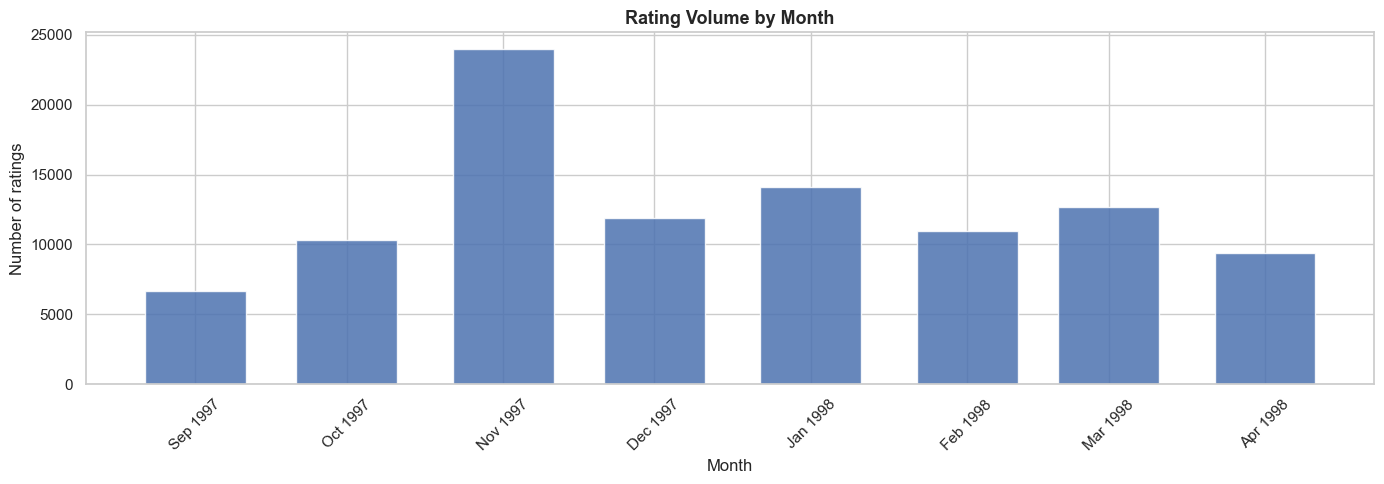

In [22]:
ratings_per_month = (
    ratings.groupby(ratings["datetime"].dt.to_period("M"))
    .size()
    .reset_index(name="count")
)
ratings_per_month["datetime"] = ratings_per_month["datetime"].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(
    ratings_per_month["datetime"],
    ratings_per_month["count"],
    width=20,
    color="#4C72B0",
    edgecolor="white",
    alpha=0.85,
)
ax.set_title("Rating Volume by Month", fontsize=13, fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Number of ratings")
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%b %Y"))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(
    "../notebooks/fig_ml_02_ratings_per_month.png", dpi=150, bbox_inches="tight"
)
plt.show()

Ratings per user statistics:
  Unique users     : 943
  Average ratings  : 106.0
  Median           : 65
  Minimum          : 20
  Maximum          : 737
  Users >= 20      : 943 (100.0%)


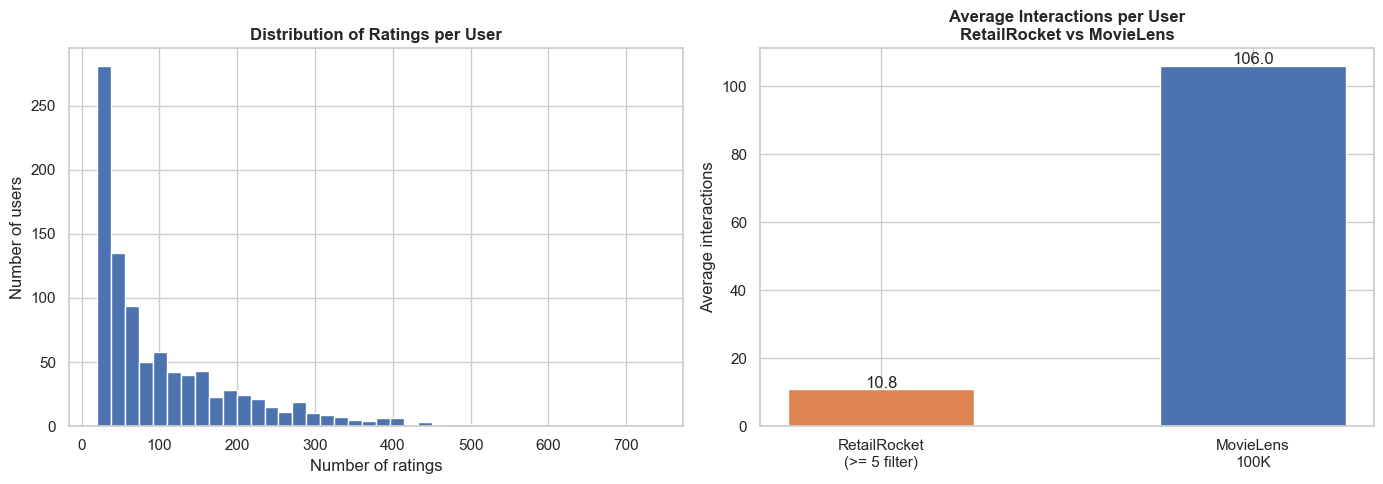

In [23]:
ratings_per_user = ratings.groupby("user_id").size()

print("Ratings per user statistics:")
print(f"  Unique users     : {len(ratings_per_user)}")
print(f"  Average ratings  : {ratings_per_user.mean():.1f}")
print(f"  Median           : {ratings_per_user.median():.0f}")
print(f"  Minimum          : {ratings_per_user.min()}")
print(f"  Maximum          : {ratings_per_user.max()}")
print(
    f"  Users >= 20      : {(ratings_per_user >= 20).sum()} ({(ratings_per_user >= 20).mean():.1%})"
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(
    ratings_per_user.values,
    bins=40,
    color="#4C72B0",
    edgecolor="white",
)
axes[0].set_title("Distribution of Ratings per User", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Number of ratings")
axes[0].set_ylabel("Number of users")

# Compare with RetailRocket
datasets = ["RetailRocket\n(>= 5 filter)", "MovieLens\n100K"]
averages = [255398 / 23620, ratings_per_user.mean()]
colors = ["#DD8452", "#4C72B0"]
axes[1].bar(datasets, averages, color=colors, edgecolor="white", width=0.5)
axes[1].set_title(
    "Average Interactions per User\nRetailRocket vs MovieLens",
    fontsize=12,
    fontweight="bold",
)
axes[1].set_ylabel("Average interactions")
for i, v in enumerate(averages):
    axes[1].text(i, v + 0.5, f"{v:.1f}", ha="center", fontsize=12, fontweight="500")

plt.tight_layout()
plt.savefig("../notebooks/fig_ml_03_ratings_users.png", dpi=150, bbox_inches="tight")
plt.show()

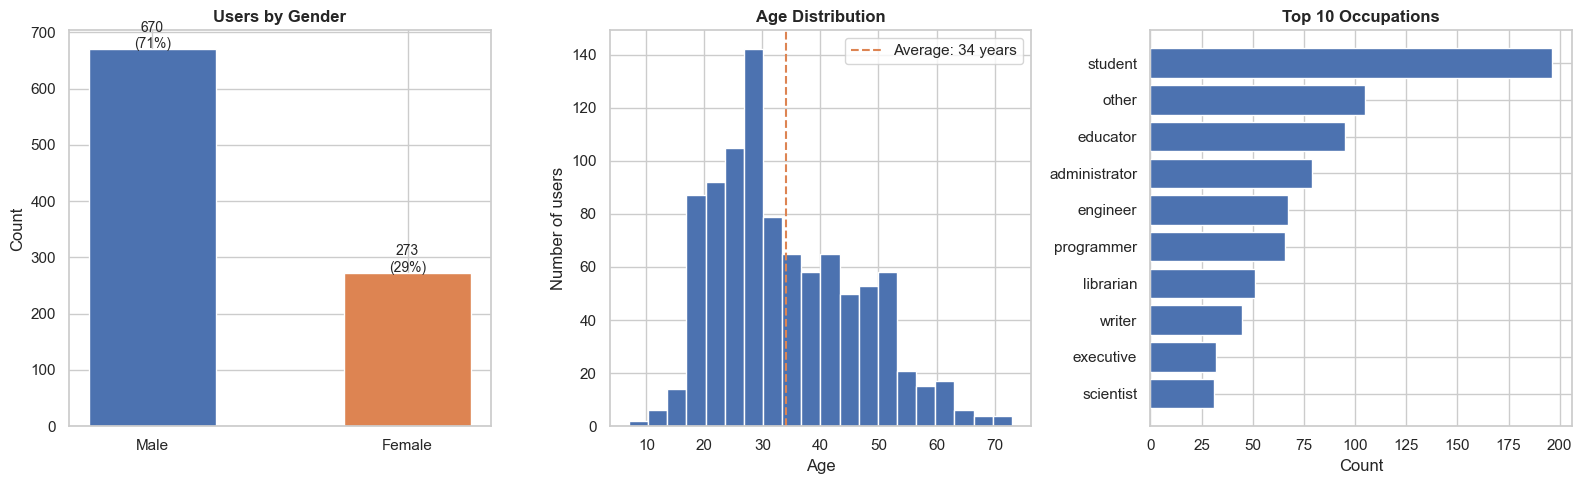

Average age : 34 years
Median age  : 31 years
% Male      : 71.0%


In [24]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Gender distribution
gender_counts = users["gender"].value_counts()
axes[0].bar(
    ["Male", "Female"],
    gender_counts.values,
    color=["#4C72B0", "#DD8452"],
    edgecolor="white",
    width=0.5,
)
axes[0].set_title("Users by Gender", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Count")
for i, v in enumerate(gender_counts.values):
    pct = v / len(users) * 100
    axes[0].text(i, v + 2, f"{v}\n({pct:.0f}%)", ha="center", fontsize=10)

# Age distribution
axes[1].hist(
    users["age"].values,
    bins=20,
    color="#4C72B0",
    edgecolor="white",
)
axes[1].set_title("Age Distribution", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Age")
axes[1].set_ylabel("Number of users")
axes[1].axvline(
    users["age"].mean(),
    color="#DD8452",
    linestyle="--",
    label=f"Average: {users['age'].mean():.0f} years",
)
axes[1].legend()

# Top 10 occupations
top_occupations = users["occupation"].value_counts().head(10)
axes[2].barh(
    top_occupations.index,
    top_occupations.values,
    color="#4C72B0",
    edgecolor="white",
)
axes[2].set_title("Top 10 Occupations", fontsize=12, fontweight="bold")
axes[2].set_xlabel("Count")
axes[2].invert_yaxis()

plt.tight_layout()
plt.savefig("../notebooks/fig_ml_04_demographics.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Average age : {users['age'].mean():.0f} years")
print(f"Median age  : {users['age'].median():.0f} years")
print(f"% Male      : {(users['gender'] == 'M').mean():.1%}")

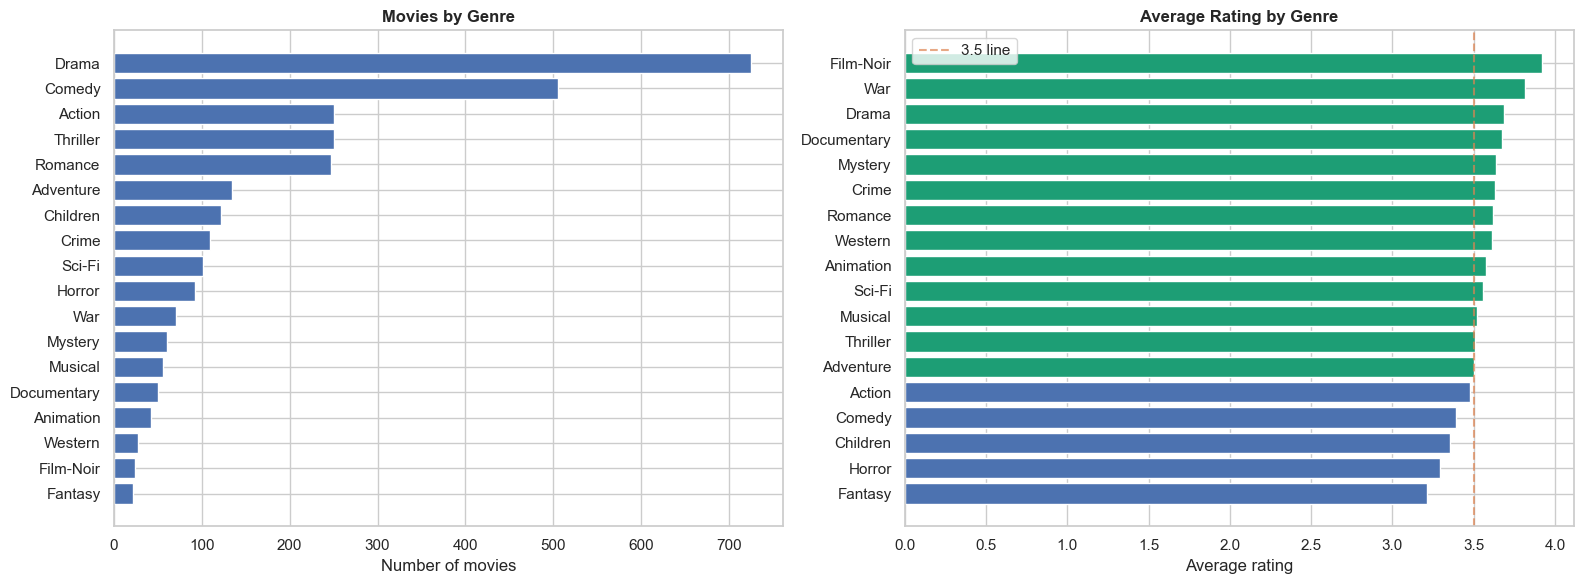

In [25]:
# Genre columns in the dataset
genres = [
    "Action",
    "Adventure",
    "Animation",
    "Children",
    "Comedy",
    "Crime",
    "Documentary",
    "Drama",
    "Fantasy",
    "Film-Noir",
    "Horror",
    "Musical",
    "Mystery",
    "Romance",
    "Sci-Fi",
    "Thriller",
    "War",
    "Western",
]

genre_counts = movies[genres].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Movies by genre
axes[0].barh(
    genre_counts.index,
    genre_counts.values,
    color="#4C72B0",
    edgecolor="white",
)
axes[0].set_title("Movies by Genre", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Number of movies")
axes[0].invert_yaxis()

# Average rating by genre
movie_ratings = ratings.merge(movies[["item_id"] + genres], on="item_id")
rating_by_genre = {}
for g in genres:
    genre_movies = movie_ratings[movie_ratings[g] == 1]["rating"]
    if len(genre_movies) > 0:
        rating_by_genre[g] = genre_movies.mean()

rating_genre_df = pd.Series(rating_by_genre).sort_values(ascending=False)
rating_colors = ["#1D9E75" if v >= 3.5 else "#4C72B0" for v in rating_genre_df.values]
axes[1].barh(
    rating_genre_df.index,
    rating_genre_df.values,
    color=rating_colors,
    edgecolor="white",
)
axes[1].set_title("Average Rating by Genre", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Average rating")
axes[1].axvline(x=3.5, color="#DD8452", linestyle="--", alpha=0.7, label="3.5 line")
axes[1].invert_yaxis()
axes[1].legend()

plt.tight_layout()
plt.savefig("../notebooks/fig_ml_05_genres.png", dpi=150, bbox_inches="tight")
plt.show()

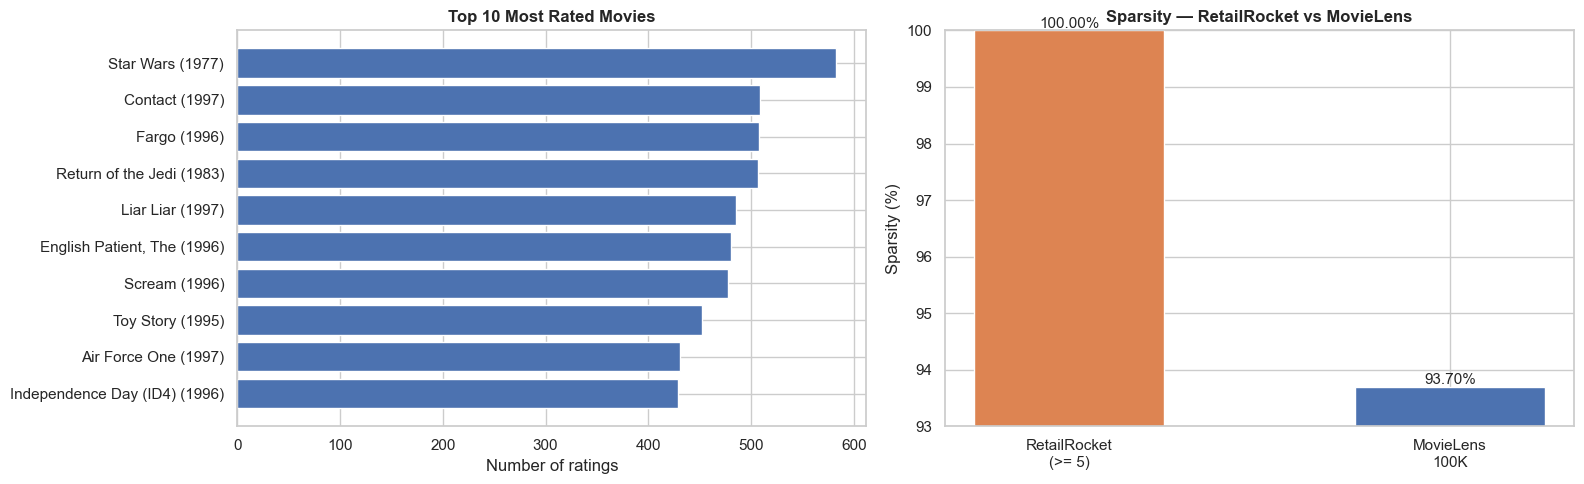

MovieLens sparsity: 93.6953%
RetailRocket sparsity (>= 5): 99.9994%

MovieLens is 6.30x less sparse!


In [26]:
# Top 10 most rated movies
top_movies = (
    ratings.groupby("item_id")
    .size()
    .reset_index(name="n_ratings")
    .merge(movies[["item_id", "title"]], on="item_id")
    .nlargest(10, "n_ratings")
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].barh(
    top_movies["title"].str[:30],
    top_movies["n_ratings"],
    color="#4C72B0",
    edgecolor="white",
)
axes[0].set_title("Top 10 Most Rated Movies", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Number of ratings")
axes[0].invert_yaxis()

# Sparsity
n_users = ratings["user_id"].nunique()
n_items = ratings["item_id"].nunique()
n_ratings = len(ratings)
sparsity = (1 - n_ratings / (n_users * n_items)) * 100

# Sparsity comparison
labels = ["RetailRocket\n(>= 5)", "MovieLens\n100K"]
sparsities = [99.9994, sparsity]
axes[1].bar(
    labels,
    sparsities,
    color=["#DD8452", "#4C72B0"],
    edgecolor="white",
    width=0.5,
)
axes[1].set_title(
    "Sparsity — RetailRocket vs MovieLens", fontsize=12, fontweight="bold"
)
axes[1].set_ylabel("Sparsity (%)")
axes[1].set_ylim([93, 100])
for i, v in enumerate(sparsities):
    axes[1].text(i, v + 0.05, f"{v:.2f}%", ha="center", fontsize=11, fontweight="500")

plt.tight_layout()
plt.savefig("../notebooks/fig_ml_06_top_movies.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"MovieLens sparsity: {sparsity:.4f}%")
print("RetailRocket sparsity (>= 5): 99.9994%")
print(f"\nMovieLens is {99.9994 - sparsity:.2f}x less sparse!")